In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
import keras
from keras import layers, regularizers
layers = keras.layers

In [11]:
def plot_examples(X, Y, n=10):
    """ Plot the first n examples for each of the 10 classes in the CIFAR dataset X, Y """
    fig, axes = plt.subplots(n, 10, figsize=(10, n))
    for l in range(10):
        axes[0, l].set_title(cifar10_labels[l], fontsize="smaller")
        m = np.squeeze(Y) == l  # boolean mask: True for all images of label l
        for i in range(n):
            image = X[m][i].astype("uint8")  # imshow expects uint8
            ax = axes[i, l]
            ax.imshow(image, origin="upper")
            ax.set(xticks=[], yticks=[])
    return fig, ax


def plot_prediction(X, Y, Y_predict):
    """
    Plot image X along with predicted probabilities Y_predict.
    X: CIFAR image, shape = (32, 32, 3)
    Y: CIFAR label, one-hot encoded, shape = (10)
    Y_predict: predicted probabilities, shape = (10)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    # plot image
    ax1.imshow(X.astype("uint8"), origin="upper")
    ax1.set(xticks=[], yticks=[])

    # plot probabilities
    ax2.barh(np.arange(10), Y_predict, align="center")
    ax2.set(xlim=(0, 1), xlabel="Score", yticks=[])
    for i in range(10):
        c = "red" if (i == np.argmax(Y)) else "black"
        ax2.text(0.05, i, cifar10_labels[i].capitalize(), ha="left", va="center", color=c)



def plot_confusion(Y_true, Y_predict):
    """
    Plot confusion matrix
    Y_true:    array of true classifications (0-9), shape = (N)
    Y_predict: array of predicted classifications (0-9), shape = (N)
    """
    C = np.histogram2d(Y_true, Y_predict, bins=np.linspace(-0.5, 9.5, 11))[0]
    Cn = C / np.sum(C, axis=1)

    fig = plt.figure()
    plt.imshow(Cn, interpolation="nearest", vmin=0, vmax=1, cmap=plt.cm.YlGnBu)
    plt.colorbar()
    plt.xlabel("prediction")
    plt.ylabel("truth")
    plt.xticks(range(10), cifar10_labels, rotation="vertical")
    plt.yticks(range(10), cifar10_labels)
    for x in range(10):
        for y in range(10):
            plt.annotate("%i" % C[x, y], xy=(y, x), ha="center", va="center")



In [12]:

# X: images, Y: labels
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("images, shape = ", x_train.shape)
print("labels, shape = ", y_train.shape)

cifar10_labels = np.array([
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'])

images, shape =  (50000, 32, 32, 3)
labels, shape =  (50000, 1)


In [13]:
# convert labels ("0"-"9") to one-hot encodings, "0" = (1, 0, ... 0) and so on
y_train_onehot = keras.utils.to_categorical(y_train, 10)
y_test_onehot = keras.utils.to_categorical(y_test, 10)[:8000]
y_valid_onehot = keras.utils.to_categorical(y_test, 10)[8000:]

In [14]:
# 1. Define the Residual Block
def residual_block(x, filters, strides=1):
    shortcut = x
    
    # If dimensions change, adjust the shortcut path to match
    if strides != 1 or x.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, kernel_size=1, strides=strides, use_bias=False, 
                                 kernel_regularizer=regularizers.l2(5e-4))(x)
        shortcut = layers.BatchNormalization()(shortcut)

    # First convolution in the block
    x = layers.Conv2D(filters, kernel_size=3, strides=strides, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # Second convolution
    x = layers.Conv2D(filters, kernel_size=3, strides=1, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)

    # Add the shortcut to the main path, then activate
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

# 2. Build the Model Architecture
def build_cifar_resnet18(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    
    # --- DATA AUGMENTATION ---
    # Randomly shifts the image by up to 12.5% (4 pixels) to mimic padding/cropping
    x = layers.RandomTranslation(height_factor=0.125, width_factor=0.125, fill_mode="constant")(inputs)
    x = layers.RandomFlip("horizontal")(x)
    
    # --- NORMALIZATION ---
    # Scales images using CIFAR-10 specific means and variances
    x = layers.Normalization(
        mean=[0.4914, 0.4822, 0.4465], 
        variance=[0.0409, 0.0397, 0.0404] # Keras uses variance (Standard Deviation squared)
    )(x)

    # --- CRITICAL CIFAR MODIFICATION ---
    # 3x3 kernel, stride 1, and NO MaxPool layer so the image doesn't shrink too fast
    x = layers.Conv2D(64, kernel_size=3, strides=1, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # --- STACK RESIDUAL BLOCKS --- 
    x = residual_block(x, filters=64, strides=1)
    x = residual_block(x, filters=64, strides=1)
    
    x = residual_block(x, filters=128, strides=2)
    x = residual_block(x, filters=128, strides=1)
    
    x = residual_block(x, filters=256, strides=2)
    x = residual_block(x, filters=256, strides=1)
    
    x = residual_block(x, filters=512, strides=2)
    x = residual_block(x, filters=512, strides=1)

    # --- FINAL CLASSIFICATION HEAD ---
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, kernel_regularizer=regularizers.l2(5e-4))(x)

    return keras.Model(inputs, outputs, name="CIFAR_ResNet18")

# model = build_cifar_resnet18()

In [15]:
# print(model.summary())

In [16]:
# VGG Net
def build_cifar_vgg(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    
    # --- DATA AUGMENTATION ---
    x = layers.RandomTranslation(height_factor=0.125, width_factor=0.125, fill_mode="constant")(inputs)
    x = layers.RandomFlip("horizontal")(x)
    
    # --- NORMALIZATION ---
    x = layers.Normalization(
        mean=[0.4914, 0.4822, 0.4465], 
        variance=[0.0409, 0.0397, 0.0404]
    )(x)

    # --- VGG-STYLE CONVOLUTIONAL BLOCKS ---
    x = layers.Conv2D(64, kernel_size=3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(64, kernel_size=3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)  # 16x16

    x = layers.Conv2D(128, kernel_size=3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(128, kernel_size=3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)  # 8x8

    x = layers.Conv2D(256, kernel_size=3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(256, kernel_size=3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(256, kernel_size=3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)  # 4x4

    # --- FINAL CLASSIFICATION HEAD ---
    x = layers.Flatten()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax", kernel_regularizer=regularizers.l2(5e-4))(x)

    return keras.Model(inputs, outputs, name="CIFAR_VGG")

model = build_cifar_vgg()

print(model.summary())

Model: "CIFAR_VGG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_1            │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 256)      │       589,82

 Total params: 1,779,914 (6.79 MB)

 Trainable params: 1,777,610 (6.78 MB)

 Non-trainable params: 2,304 (9.00 KB)

None


In [17]:
epochs = 50
batch_size = 512
steps_per_epoch = 50000 // batch_size  # 50,000 CIFAR-10 training images

# Slowly decay the learning rate following a cosine curve
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.1,
    decay_steps=epochs * steps_per_epoch
)

# SGD with Momentum pairs best with Cosine Annealing
optimizer = keras.optimizers.SGD(
    learning_rate=lr_schedule, 
    momentum=0.9
)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)


In [18]:
history = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test))

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step - accuracy: 0.1177 - loss: 6.8527 - val_accuracy: 0.1017 - val_loss: 49.0211
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - accuracy: 0.1435 - loss: 4.6509 - val_accuracy: 0.1617 - val_loss: 4.5688
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.1609 - loss: 4.1924 - val_accuracy: 0.1835 - val_loss: 3.9768
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.1861 - loss: 3.8046 - val_accuracy: 0.1042 - val_loss: 3.7727
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - accuracy: 0.2230 - loss: 3.4266 - val_accuracy: 0.1659 - val_loss: 3.4054
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.2465 - loss: 3.1133 - val_accuracy: 0.2183 - val_loss: 3.0701
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.2523 - loss: 2.8633 - val_accuracy: 0.1882 - val_loss: 3.0621
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.2531 - loss: 2.6834 - val_acc

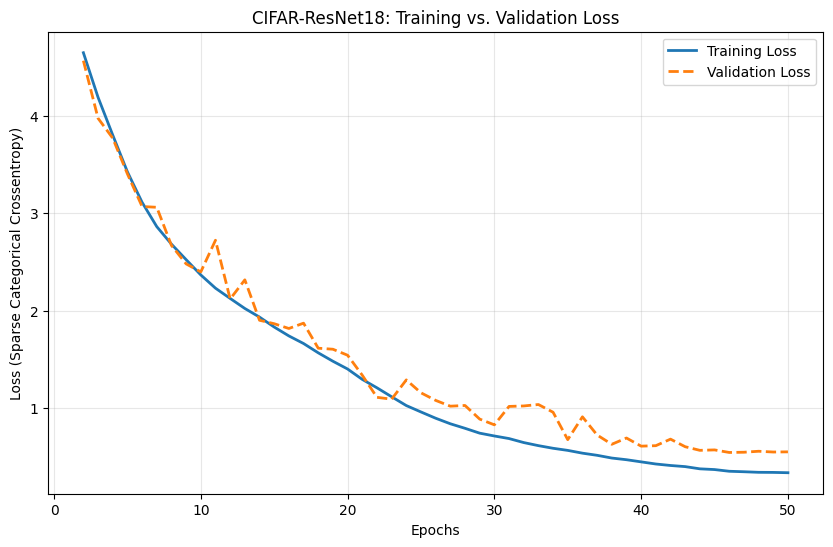

In [19]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(10, 6))

# Plot both lines
plt.plot(epochs[1:], loss[1:], label='Training Loss', linewidth=2, linestyle='-')
plt.plot(epochs[1:], val_loss[1:], label='Validation Loss', linewidth=2, linestyle='--')

# Formatting the chart
plt.title('CIFAR-ResNet18: Training vs. Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (Sparse Categorical Crossentropy)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Display the plot
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


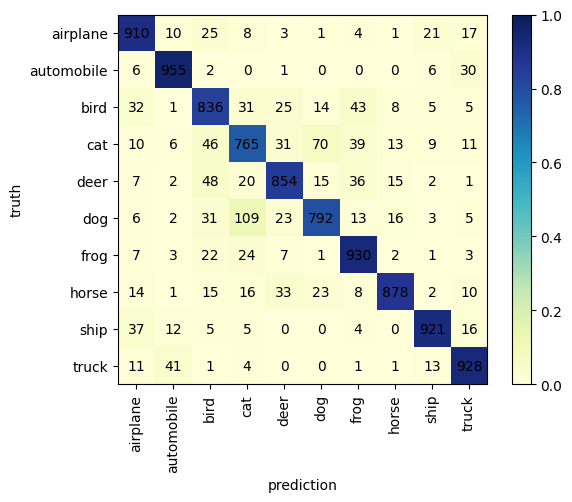

In [20]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate predictions
# Note: Because we used from_logits=True, these are raw scores, not percentages. 
# However, np.argmax still works perfectly because the highest score = the chosen class.
y_predict = model.predict(x_test, batch_size=batch_size)
y_predict_cl = np.argmax(y_predict, axis=1)

# 2. Format the actual test labels
# CIFAR-10 y_test is shaped (10000, 1). We use flatten() to make it a 1D array of (10000,)
# so it matches the shape of y_predict_cl perfectly.
y_test_cl = y_test.flatten()

# 3. Generate the Confusion Matrix
cm = plot_confusion(y_test_cl, y_predict_cl)

With a validation accuracy of 94% this network architecture is extremely good. 
The model I used is only my implementation of a very popular CNN.
The accuracy gain over the other two attemps at CIFAR 10 is impressive. My evaluation of it is limited because I forgot to save the model and i only added barebones evaluation before starting the training. It took about 6 hours until the training was finished. Because I didnt have time at that point i closed my laptop and over night it installed an update, restarting the computer. 

In [21]:
import os

os.makedirs("models", exist_ok=True)

model.save("models/cifar_{}.keras".format(model.name))

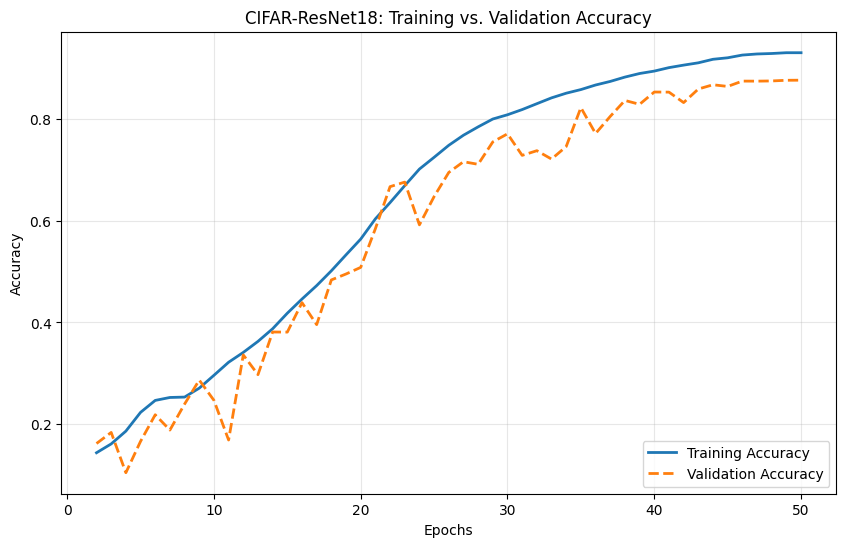

In [22]:
# plot accuracy of training and validation
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, len(accuracy) + 1)

plt.figure(figsize=(10, 6))
# Plot both lines
plt.plot(epochs[1:], accuracy[1:], label='Training Accuracy', linewidth=2, linestyle='-')
plt.plot(epochs[1:], val_accuracy[1:], label='Validation Accuracy', linewidth=2, linestyle='--')
# Formatting the chart
plt.title('CIFAR-ResNet18: Training vs. Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
# Display the plot
plt.show()